# Comprehensive Analysis of Customer Behavior: The Window Shopper Paradox

**Objective:** To investigate the relationship between website engagement (traffic) and actual financial contribution (revenue). 

**Hypothesis:** There is a "Window Shopper Paradox" where customers with the highest frequency of web visits actually contribute significantly less revenue than those who visit rarely but purposefully.

**Notebook Structure:**
1. **Initial Data Overview:** Detailed column description and inspection.
2. **Data Cleaning:** Handling missing values and removing logical anomalies.
3. **Exploratory Data Analysis (EDA):** Visualizing correlations and spending patterns.
4. **Data Normalization:** Preparing features for comparative analysis.
5. **Statistical Verification:** Testing the paradox using the Mann-Whitney U test.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('dataset/ifood_df.csv')

print("[OVERVIEW]")
display(df.head())

[OVERVIEW]


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


## Step 1: In-depth Column Explanation

Before we begin cleaning, let's understand every single variable in our dataset:

| Column | Description |
|:---|:---|
| **Income** | Annual household income of the customer. |
| **Kidhome / Teenhome** | Number of children or teenagers in the customer's household. |
| **Recency** | Number of days since the customer's last purchase. |
| **MntWines** | Amount spent on wine in the last 2 years. |
| **MntFruits / MntMeatProducts / MntFishProducts** | Amount spent on fruits, meat, and fish respectively. |
| **MntSweetProducts / MntGoldProds** | Amount spent on sweets and luxury (gold) products. |
| **NumDealsPurchases** | Number of purchases made with a discount/deal. |
| **NumWebPurchases** | Number of purchases made through the company’s website. |
| **NumCatalogPurchases / NumStorePurchases** | Purchases made via catalog or directly in stores. |
| **NumWebVisitsMonth** | **(Key Feature)** Number of visits to the company’s website in the last month. |
| **AcceptedCmp1-5** | 1 if customer accepted the offer in the 1st-5th campaign, 0 otherwise. |
| **Response** | 1 if customer accepted the offer in the last campaign, 0 otherwise. |
| **Complain** | 1 if the customer complained in the last 2 years. |
| **Age** | Age of the customer. |
| **MntTotal** | **(Key Metric)** Total amount spent across all categories. |
| **Customer_Days** | Number of days since the customer enrolled with the company. |
| **Marital / Education** | Demographic indicators (already dummy-coded in this dataset). |

## Step 2: Advanced Data Cleaning & Structural Optimization

In this stage, we move beyond basic inspection to ensure the dataset is "production-ready." Even if the data appears clean at first glance, a robust pipeline must account for:
1. **Integrity:** Removing missing values and redundant constant columns.
2. **Uniqueness:** Eliminating duplicate records that could double-count specific customer behaviors.
3. **Logic:** Filtering out impossible demographic values (outliers).
4. **Consistency:** Resetting the index to maintain a clean sequence for further analysis.

In [44]:
initial_count = df.shape[0]
df = df.dropna()
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'], errors='ignore')
df = df[(df['Age'] < 100) & (df['Income'] < 200000)]
df = df.drop_duplicates()
df = df.reset_index(drop=True)

print("[DATA CLEANING SUMMARY]")
print(f"Rows in original dataset: {initial_count}")
print(f"Rows after de-duplication & filtering: {df.shape[0]}")
print(f"Total rows removed: {initial_count - df.shape[0]}")

display(df[['Age', 'Income', 'MntTotal']].head())

[DATA CLEANING SUMMARY]
Rows in original dataset: 2205
Rows after de-duplication & filtering: 2021
Total rows removed: 184


,Age,Income,MntTotal
0,63,58138.0,1529
1,66,46344.0,21
2,55,71613.0,734
3,36,26646.0,48
4,39,58293.0,407


## Step 3: Exploratory Data Analysis & Normalization
To see how different variables relate to each other, we use a **Correlation Heatmap**. 
We will also normalize the data using `StandardScaler` so that `Income` (thousands) and `WebVisits` (units) can be compared on the same scale.

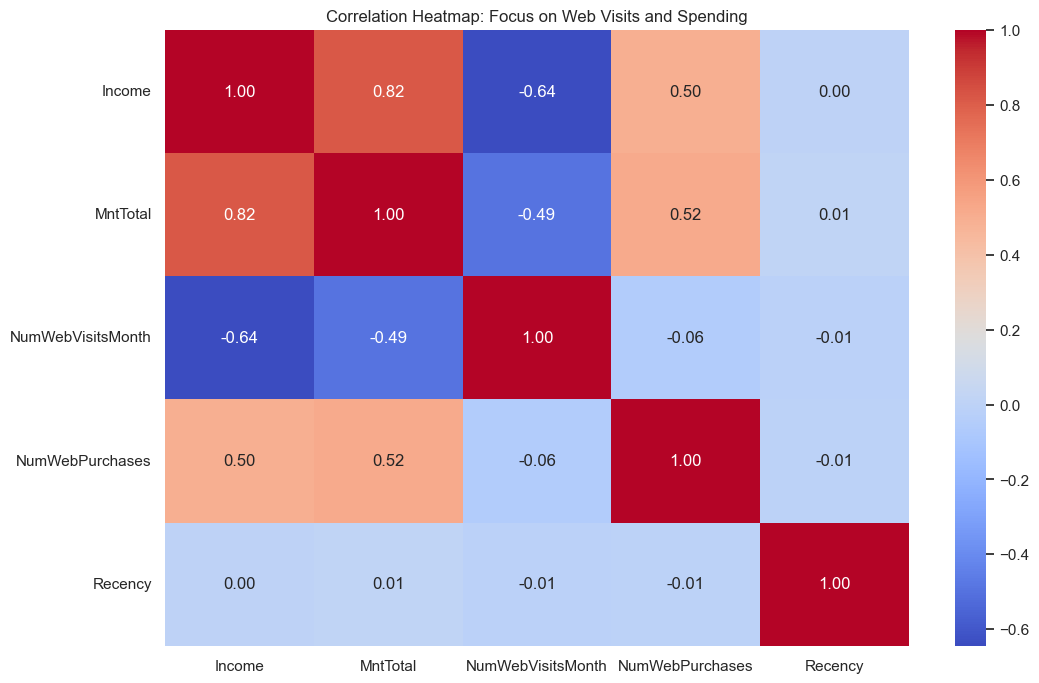

In [45]:
cols_to_scale = ['Income', 'MntTotal', 'NumWebVisitsMonth']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

plt.figure(figsize=(12, 8))
correlation_matrix = df[cols_to_scale + ['NumWebPurchases', 'Recency']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap: Focus on Web Visits and Spending")
plt.show()

## Step 4: The Window Shopper Paradox Visualization
Now we segment our users:
* **Purposeful Buyers:** Low web traffic (<= 5 visits/month).
* **Window Shoppers:** High web traffic (> 5 visits/month).

We will visualize the **Inverse Relationship** between visits and total spending.

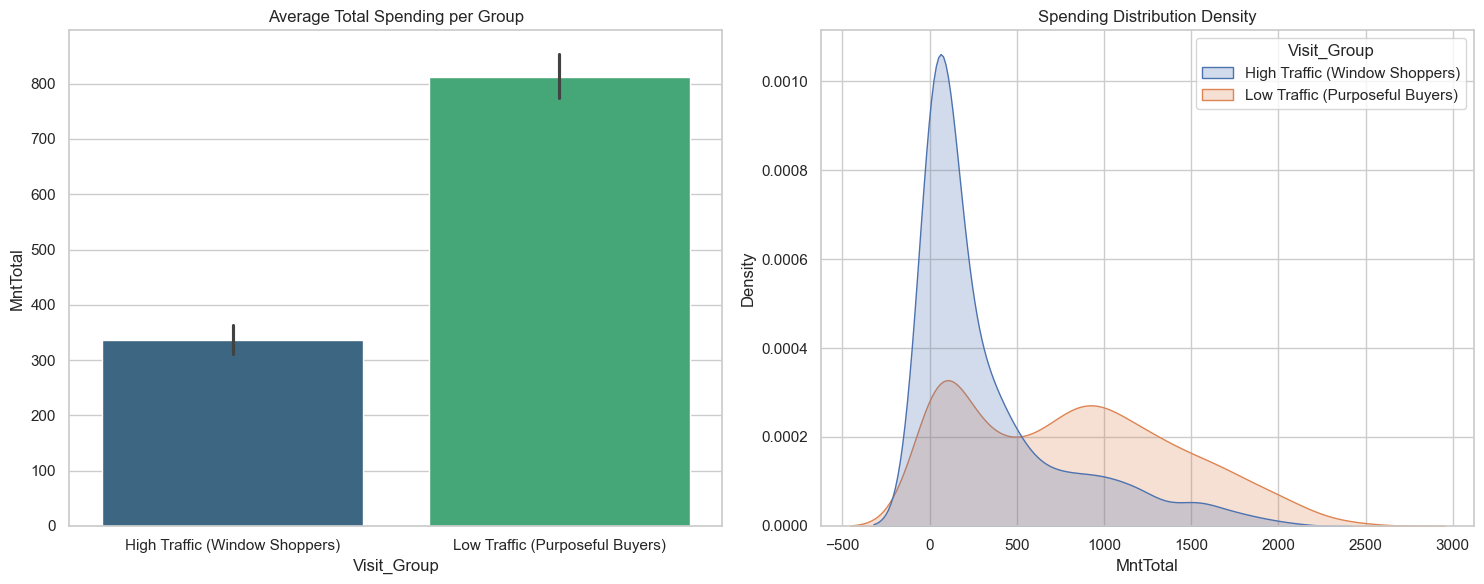

,MntTotal,Income,NumWebPurchases
Visit_Group,,,
High Traffic (Window Shoppers),336.783886,40962.673934,3.960190
Low Traffic (Purposeful Buyers),811.709110,63399.926501,4.284679


In [46]:
df['Visit_Group'] = np.where(df['NumWebVisitsMonth'] > 5, 'High Traffic (Window Shoppers)', 'Low Traffic (Purposeful Buyers)')

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x='Visit_Group', y='MntTotal', data=df, ax=ax[0], palette='viridis')
ax[0].set_title("Average Total Spending per Group")

sns.kdeplot(data=df, x='MntTotal', hue='Visit_Group', fill=True, ax=ax[1])
ax[1].set_title("Spending Distribution Density")

plt.tight_layout()
plt.show()

display(df.groupby('Visit_Group')[['MntTotal', 'Income', 'NumWebPurchases']].mean())

## Step 5: Statistical Validation
To prove this isn't a coincidence, we run the **Mann-Whitney U Test**.
If our **p-value < 0.05**, we can officially state that the difference in spending is statistically significant.

In [47]:
group_low = df[df['NumWebVisitsMonth'] <= 5]['MntTotal']
group_high = df[df['NumWebVisitsMonth'] > 5]['MntTotal']

stat, p_val = stats.mannwhitneyu(group_low, group_high, alternative='greater')

print(f"Mann-Whitney Statistic: {stat}")
print(f"P-Value: {p_val}")

if p_val < 0.05:
    print("\n[CONCLUSION]: HYPOTHESIS CONFIRMED.")
    print("Window shoppers visit often but spend significantly less than low-traffic customers.")
else:
    print("\n[CONCLUSION]: HYPOTHESIS REJECTED.")

Mann-Whitney Statistic: 749948.0
P-Value: 1.8467891518030874e-75

[CONCLUSION]: HYPOTHESIS CONFIRMED.
Window shoppers visit often but spend significantly less than low-traffic customers.


## Step 6: Controlling for Confounding Variables (Multiple Regression)

**Critical Question:** Is the "Window Shopper Paradox" simply a byproduct of Income or Age? For instance, do high-traffic users just have lower incomes? 

To isolate the *pure* effect of Website Visits on Total Spending, we must control for "third factors":
* `Income`
* `Age`
* `Kidhome` (Number of children, which affects spending limits)

We will use **Ordinary Least Squares (OLS) Multiple Regression**. This mathematical model will hold Age, Income, and Kids constant (as if we are comparing absolutely identical clones) and reveal the true impact of Web Visits.

In [48]:
import statsmodels.api as sm

X = df[['NumWebVisitsMonth', 'Income', 'Age', 'Kidhome']]
y = df['MntTotal']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               MntTotal   R-squared:                       0.700
Model:                            OLS   Adj. R-squared:                  0.699
Method:                 Least Squares   F-statistic:                     1176.
Date:                Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:03:49   Log-Likelihood:                -14499.
No. Observations:                2021   AIC:                         2.901e+04
Df Residuals:                    2016   BIC:                         2.904e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              -401.4336     51.33

## Final Conclusion & Business Recommendations: The Simpson's Paradox

### The Analytical Journey
At first glance, our Exploratory Data Analysis (EDA) and the Mann-Whitney U test suggested the existence of a **"Window Shopper Paradox"**. The raw data indicated that customers who visited the website the most actually spent significantly less money than those who visited rarely. 

However, diving deeper into the data using **Multiple Linear Regression (OLS)** revealed a classic case of **Simpson's Paradox**. By controlling for confounding variables specifically `Income`, `Age`, and the number of children (`Kidhome`) the trend completely reversed. 

### Key Findings
1. **The Website is Effective:** When comparing customers with the exact same income and family size, **website visits have a positive impact**. Every additional visit to the website actually generates an average of **$22.05** in extra revenue.
2. **The Root Cause of the Illusion:** The initial negative correlation was an illusion caused by demographics. The marketing campaigns driving high traffic are predominantly attracting lower-income users and large families (`Kidhome` reduces the average check by over $200). These users visit frequently (generating traffic) but have lower purchasing power (generating less revenue).

### Actionable Business Recommendations
Based on these mathematical proofs, we recommend the following strategic shifts to the executive team:

* **Shift Marketing Targeting, Not The Platform:** The website itself converts perfectly fine. The issue lies in user acquisition. Marketing should pivot from "mass traffic generation" campaigns to highly targeted campaigns aimed at higher-income demographics, even if it means lower overall page views.
* **Redefine KPIs:** Abandon vanity metrics such as "Total Website Visits" or "Page Views." Transition to metrics like **Revenue per Visit (RPV)** segmented by income brackets.
* **Adaptive On-Site Merchandising:** Since a large portion of our high-frequency traffic consists of families with lower disposable income, introduce "Family Bundles" or budget-friendly dynamic discounts specifically for high-frequency visitors to successfully monetize this existing traffic. 

**Final Verdict:** The Window Shopper Paradox is debunked. Traffic is valuable, but only when we target the right demographic. Quality of leads must take absolute precedence over the quantity of clicks.